In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
import matplotlib.pyplot as plt
from IPython.display import clear_output
print(device)


Matplotlib is building the font cache; this may take a moment.


mps


In [36]:
with open("common_vocab_corpus.txt", "r") as f:
    text = f.read()

tokens = text.lower().replace("(", "").replace(")", "").split()
vocab = sorted(set(tokens))
vocab_size = len(vocab)
print(vocab[:5])
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
encoded = [word_to_id[word] for word in tokens]
print(encoded)


['a', 'about', 'across', 'adult', 'after']
[305, 220, 333, 313, 305, 140, 305, 220, 251, 313, 305, 212, 305, 220, 269, 205, 305, 53, 305, 220, 282, 192, 305, 87, 305, 220, 206, 305, 87, 305, 220, 65, 305, 344, 305, 220, 238, 0, 35, 305, 220, 353, 0, 200, 305, 220, 89, 338, 305, 220, 93, 113, 305, 173, 333, 88, 305, 288, 305, 347, 333, 88, 305, 288, 305, 56, 229, 143, 305, 212, 305, 102, 93, 83, 15, 135, 305, 117, 331, 305, 140, 305, 302, 133, 305, 290, 305, 85, 133, 305, 214, 305, 350, 283, 305, 147, 305, 90, 285, 305, 49, 305, 196, 339, 132, 305, 52, 271, 205, 305, 24, 305, 86, 251, 143, 305, 354, 305, 32, 111, 210, 305, 320, 305, 110, 295, 143, 305, 338, 305, 137, 333, 192, 305, 107, 305, 8, 93, 120, 305, 37, 305, 221, 269, 192, 305, 220, 305, 86, 22, 15, 305, 199, 305, 52, 169, 15, 305, 32, 305, 32, 266, 143, 305, 188, 305, 140, 130, 0, 151, 305, 140, 130, 0, 25, 305, 140, 130, 0, 23, 305, 140, 130, 0, 167, 248, 305, 151, 130, 0, 296, 305, 25, 130, 0, 24, 305, 23, 130, 0, 267, 305, 

In [37]:
window_size = 2
training_pairs = []

for center_index in range(len(encoded)):
    center_word_id = encoded[center_index]
    start = max(0, center_index - window_size)
    end = min(len(encoded), center_index + window_size + 1)

    for context_index in range(start, end):
        if context_index != center_index:
            context_word_id = encoded[context_index]
            training_pairs.append((center_word_id, context_word_id))

# for ['a', 'about', 'across', 'adult', 'after']
# center is 'across'
# training pairs:
# a across
# about across
# adult across
# after across
print(f"Training Pairs ({training_pairs.__len__()}):")
print(training_pairs[:5])


Training Pairs (5174):
[(305, 220), (305, 333), (220, 305), (220, 333), (220, 313)]


In [38]:
class WordEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, word_ids):
        vectors = self.embedding(word_ids)
        logits = self.output(vectors)
        return logits

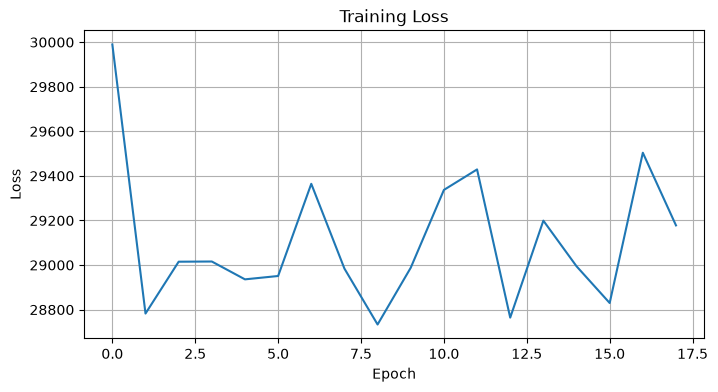

In [ ]:
vocab_size = len(vocab)
embedding_dim = 8

model = WordEmbeddingModel(vocab_size, embedding_dim).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_history=[]
for epoch in range(300):
    total_loss = 0

    for center_id, context_id in training_pairs:
        center_tensor = torch.tensor([center_id], device=device)
        context_tensor = torch.tensor([context_id], device=device)

        logits = model(center_tensor)
        loss = loss_fn(logits, context_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss)

    clear_output(wait=True)

    plt.figure(figsize=(8, 4))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.show()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, loss: {total_loss:.4f}")
